# 06 — Final Master Test-Unseen Benchmark & Comprehensive Model Evaluation

> **Master Plan Phase 5 Protocol (§0, §2, §5, §6):** This benchmark evaluation is executed **ONCE ONLY** on the completely frozen `test_unseen.csv` (19,998 domains, 10,000 DGA across 5 unseen families + 9,998 Alexa/Tranco benign domains) after all models are fully trained.
>
> **Models Evaluated:**
> 1. **Random Forest Baseline** (11 lexical/statistical features)
> 2. **XGBoost Baseline** (11 lexical/statistical features)
> 3. **Dual-Branch Perfect (v3)** (Bi-LSTM character + FastText word sequence, 4.1M params)
> 4. **Dual-Branch Coherent** (Bi-LSTM character + FastText word sequence + 6D Semantic Cosine Coherence, 0.73M params)
> 5. **ModernBERT-Base** (149M pretrained transformer fine-tuned on full 1.26M dataset)
> 6. **Ensemble 1** (ModernBERT + Dual-Branch Perfect v3 soft voting)
> 7. **Ensemble 2** (ModernBERT + Dual-Branch Coherent soft voting)
>
> **Benchmark Anchors:**
> - **Floor:** Drichel et al. (RAID 2022) — **19.4% F1**
> - **Ceiling:** Leyva La O et al. (IEEE 2026) — **80.9% F1** (ModernBERT) / **84.6% F1** (DomBertUrl) on zero-shot wordlist families (`ngioweb` & `pizd`)
> - **Hard Supplementary Zero-Day:** `matsnu` (tested blind; paper trained on it)

In [1]:
import os, sys, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, HTML

# Paths setup
BASE_DIR = Path(r"G:\dga_killer")
REPORTS_DIR = BASE_DIR / "reports"
FIG_DIR = REPORTS_DIR / "figures"
TABLE_DIR = REPORTS_DIR / "tables"
METRIC_DIR = REPORTS_DIR / "metrics"

print(f"Reports directory: {REPORTS_DIR.resolve()}")
print(f"Figures available: {len(list(FIG_DIR.glob('*.png')))} figures")

Reports directory: G:\dga_killer\reports
Figures available: 8 figures


## 1. Master Benchmark Comparison Table

The table below compares all 7 models against the primary evaluation criteria:
- **Zero-Shot Wordlist Macro Recall** on `ngioweb` + `pizd` (directly comparable to Leyva La O et al. 2026)
- **`matsnu` Recall** (the hardest dictionary-compound zero-day)
- **Overall Wordlist Macro Recall** (`ngioweb`, `pizd`, `matsnu`)
- **Non-Wordlist Macro Recall** (`tinba`, `murofet`)
- **Benign Specificity (Legit Accuracy)** on 9,998 benign domains
- **Overall Binary F1-Score, ROC-AUC, and PR-AUC (Average Precision)**

In [2]:
benchmark_df = pd.read_csv(TABLE_DIR / "final_test_benchmark_table.csv")

# Format nicely for display
display_bench = benchmark_df.copy()
pct_cols = ["Zero-Shot WL (Ngioweb+Pizd)", "Matsnu (Hard Case)", "Overall Wordlist Macro", "Non-Wordlist Macro", "Benign Accuracy"]
for col in pct_cols:
    display_bench[col] = display_bench[col].apply(lambda x: f"{x*100:.2f}%")
for col in ["F1-Score", "ROC-AUC", "PR-AUC"]:
    display_bench[col] = display_bench[col].apply(lambda x: f"{x:.4f}")

display(HTML("<h3>Table 1: Final Test-Unseen Benchmark Comparison</h3>"))
display(display_bench)

,Model,Zero-Shot WL (Ngioweb+Pizd),Matsnu (Hard Case),Overall Wordlist Macro,Non-Wordlist Macro,Benign Accuracy,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,12.88%,9.25%,11.67%,93.45%,82.68%,0.5489,0.6771,0.7335
1,XGBoost,9.93%,0.95%,6.93%,94.03%,86.18%,0.5369,0.6577,0.7315
2,Dual-Branch (v3),30.50%,15.70%,25.57%,99.92%,85.55%,0.6516,0.7440,0.8059
3,Dual-Branch Coherent,37.75%,17.60%,31.03%,99.95%,86.23%,0.6799,0.7671,0.8239
4,ModernBERT-Base,45.45%,14.15%,35.02%,99.90%,95.56%,0.7372,0.8330,0.8787
5,Ensemble (BERT + Dual v3),42.93%,12.80%,32.88%,99.98%,94.84%,0.7244,0.7977,0.8550
6,Ensemble (BERT + Dual Coh),44.35%,14.05%,34.25%,100.00%,94.88%,0.7310,0.8085,0.8624


## 2. Per-Family Detailed Recall & Accuracy Breakdown

Breakdown across every individual family in the frozen test set:
- `ngioweb` (Wordlist DGA, n=2,000)
- `pizd` (Wordlist DGA, n=2,000)
- `matsnu` (Hard Wordlist DGA, n=2,000)
- `tinba` (Arithmetic / Non-Wordlist DGA, n=2,000)
- `murofet` (Hash / Non-Wordlist DGA, n=2,000)
- `legit` (Alexa / Tranco Benign, n=9,998)

In [3]:
with open(METRIC_DIR / "complete_evaluation_metrics.json", "r") as f:
    metrics_json = json.load(f)

fam_df = pd.DataFrame(metrics_json["per_family_breakdown"]).T
# Reorder columns logically
cols = ["ngioweb", "pizd", "matsnu", "tinba", "murofet", "legit"]
fam_df = fam_df[[c for c in cols if c in fam_df.columns]]

display_fam = fam_df.copy()
for c in display_fam.columns:
    display_fam[c] = display_fam[c].apply(lambda x: f"{x*100:.2f}%")

display(HTML("<h3>Table 2: Per-Family Recall (DGA) and Specificity (Legit)</h3>"))
display(display_fam)

,ngioweb,pizd,matsnu,tinba,murofet,legit
Random Forest,9.10%,16.65%,9.25%,93.85%,93.05%,82.68%
XGBoost,6.30%,13.55%,0.95%,94.85%,93.20%,86.18%
Dual-Branch (v3),49.85%,11.15%,15.70%,99.90%,99.95%,85.55%
Dual-Branch Coherent,57.10%,18.40%,17.60%,99.90%,100.00%,86.23%
ModernBERT-Base,68.25%,22.65%,14.15%,99.85%,99.95%,95.56%
Ensemble (BERT + Dual v3),66.40%,19.45%,12.80%,100.00%,99.95%,94.84%
Ensemble (BERT + Dual Coh),68.30%,20.40%,14.05%,100.00%,100.00%,94.88%


## 3. Comprehensive Binary Classification Metrics

Includes Balanced Accuracy, Precision, Recall, Specificity, False Positive Rate (FPR), Matthews Correlation Coefficient (MCC), and raw Confusion Matrix counts (TP, FP, TN, FN).

In [4]:
detailed_df = pd.read_csv(TABLE_DIR / "final_test_detailed_metrics.csv")
float_cols = ["Accuracy", "Balanced Acc", "Precision", "Recall", "Specificity", "FPR", "F1 (Binary)", "F1 (Macro)", "MCC", "ROC-AUC", "PR-AUC (AP)"]
display_detailed = detailed_df.copy()
for c in float_cols:
    display_detailed[c] = display_detailed[c].apply(lambda x: f"{x:.4f}")

display(HTML("<h3>Table 3: Comprehensive Diagnostic & Classification Metrics</h3>"))
display(display_detailed)

,Model,Accuracy,Balanced Acc,Precision,Recall,Specificity,FPR,F1 (Binary),F1 (Macro),MCC,ROC-AUC,PR-AUC (AP),TP,FP,TN,FN
0,Random Forest,0.6353,0.6353,0.7193,0.4438,0.8268,0.1732,0.5489,0.6214,0.2929,0.6771,0.7335,4438,1732,8266,5562
1,XGBoost,0.6397,0.6397,0.7514,0.4177,0.8618,0.1382,0.5369,0.6210,0.3119,0.6577,0.7315,4177,1382,8616,5823
2,Dual-Branch (v3),0.7043,0.7043,0.7929,0.5531,0.8555,0.1445,0.6516,0.6974,0.4286,0.7440,0.8059,5531,1445,8553,4469
3,Dual-Branch Coherent,0.7241,0.7241,0.8097,0.5860,0.8623,0.1377,0.6799,0.7188,0.4664,0.7671,0.8239,5860,1377,8621,4140
4,ModernBERT-Base,0.7826,0.7826,0.9321,0.6097,0.9556,0.0444,0.7372,0.7759,0.6025,0.8330,0.8787,6097,444,9554,3903
5,Ensemble (BERT + Dual v3),0.7728,0.7728,0.9205,0.5972,0.9484,0.0516,0.7244,0.7656,0.5827,0.7977,0.8550,5972,516,9482,4028
6,Ensemble (BERT + Dual Coh),0.7771,0.7771,0.9220,0.6055,0.9488,0.0512,0.7310,0.7704,0.5901,0.8085,0.8624,6055,512,9486,3945


## 4. Publication Visualizations (Figures 1 to 8)

### Figure 1: Receiver Operating Characteristic (ROC) Curves
Threshold-independent discrimination across all models. ModernBERT-Base achieves **0.833 AUC**, followed by Ensemble (**0.808**), Dual-Branch Coherent (**0.767**), and Dual-Branch v3 (**0.744**), all substantially outperforming Random Forest (**0.677**) and XGBoost (**0.658**).

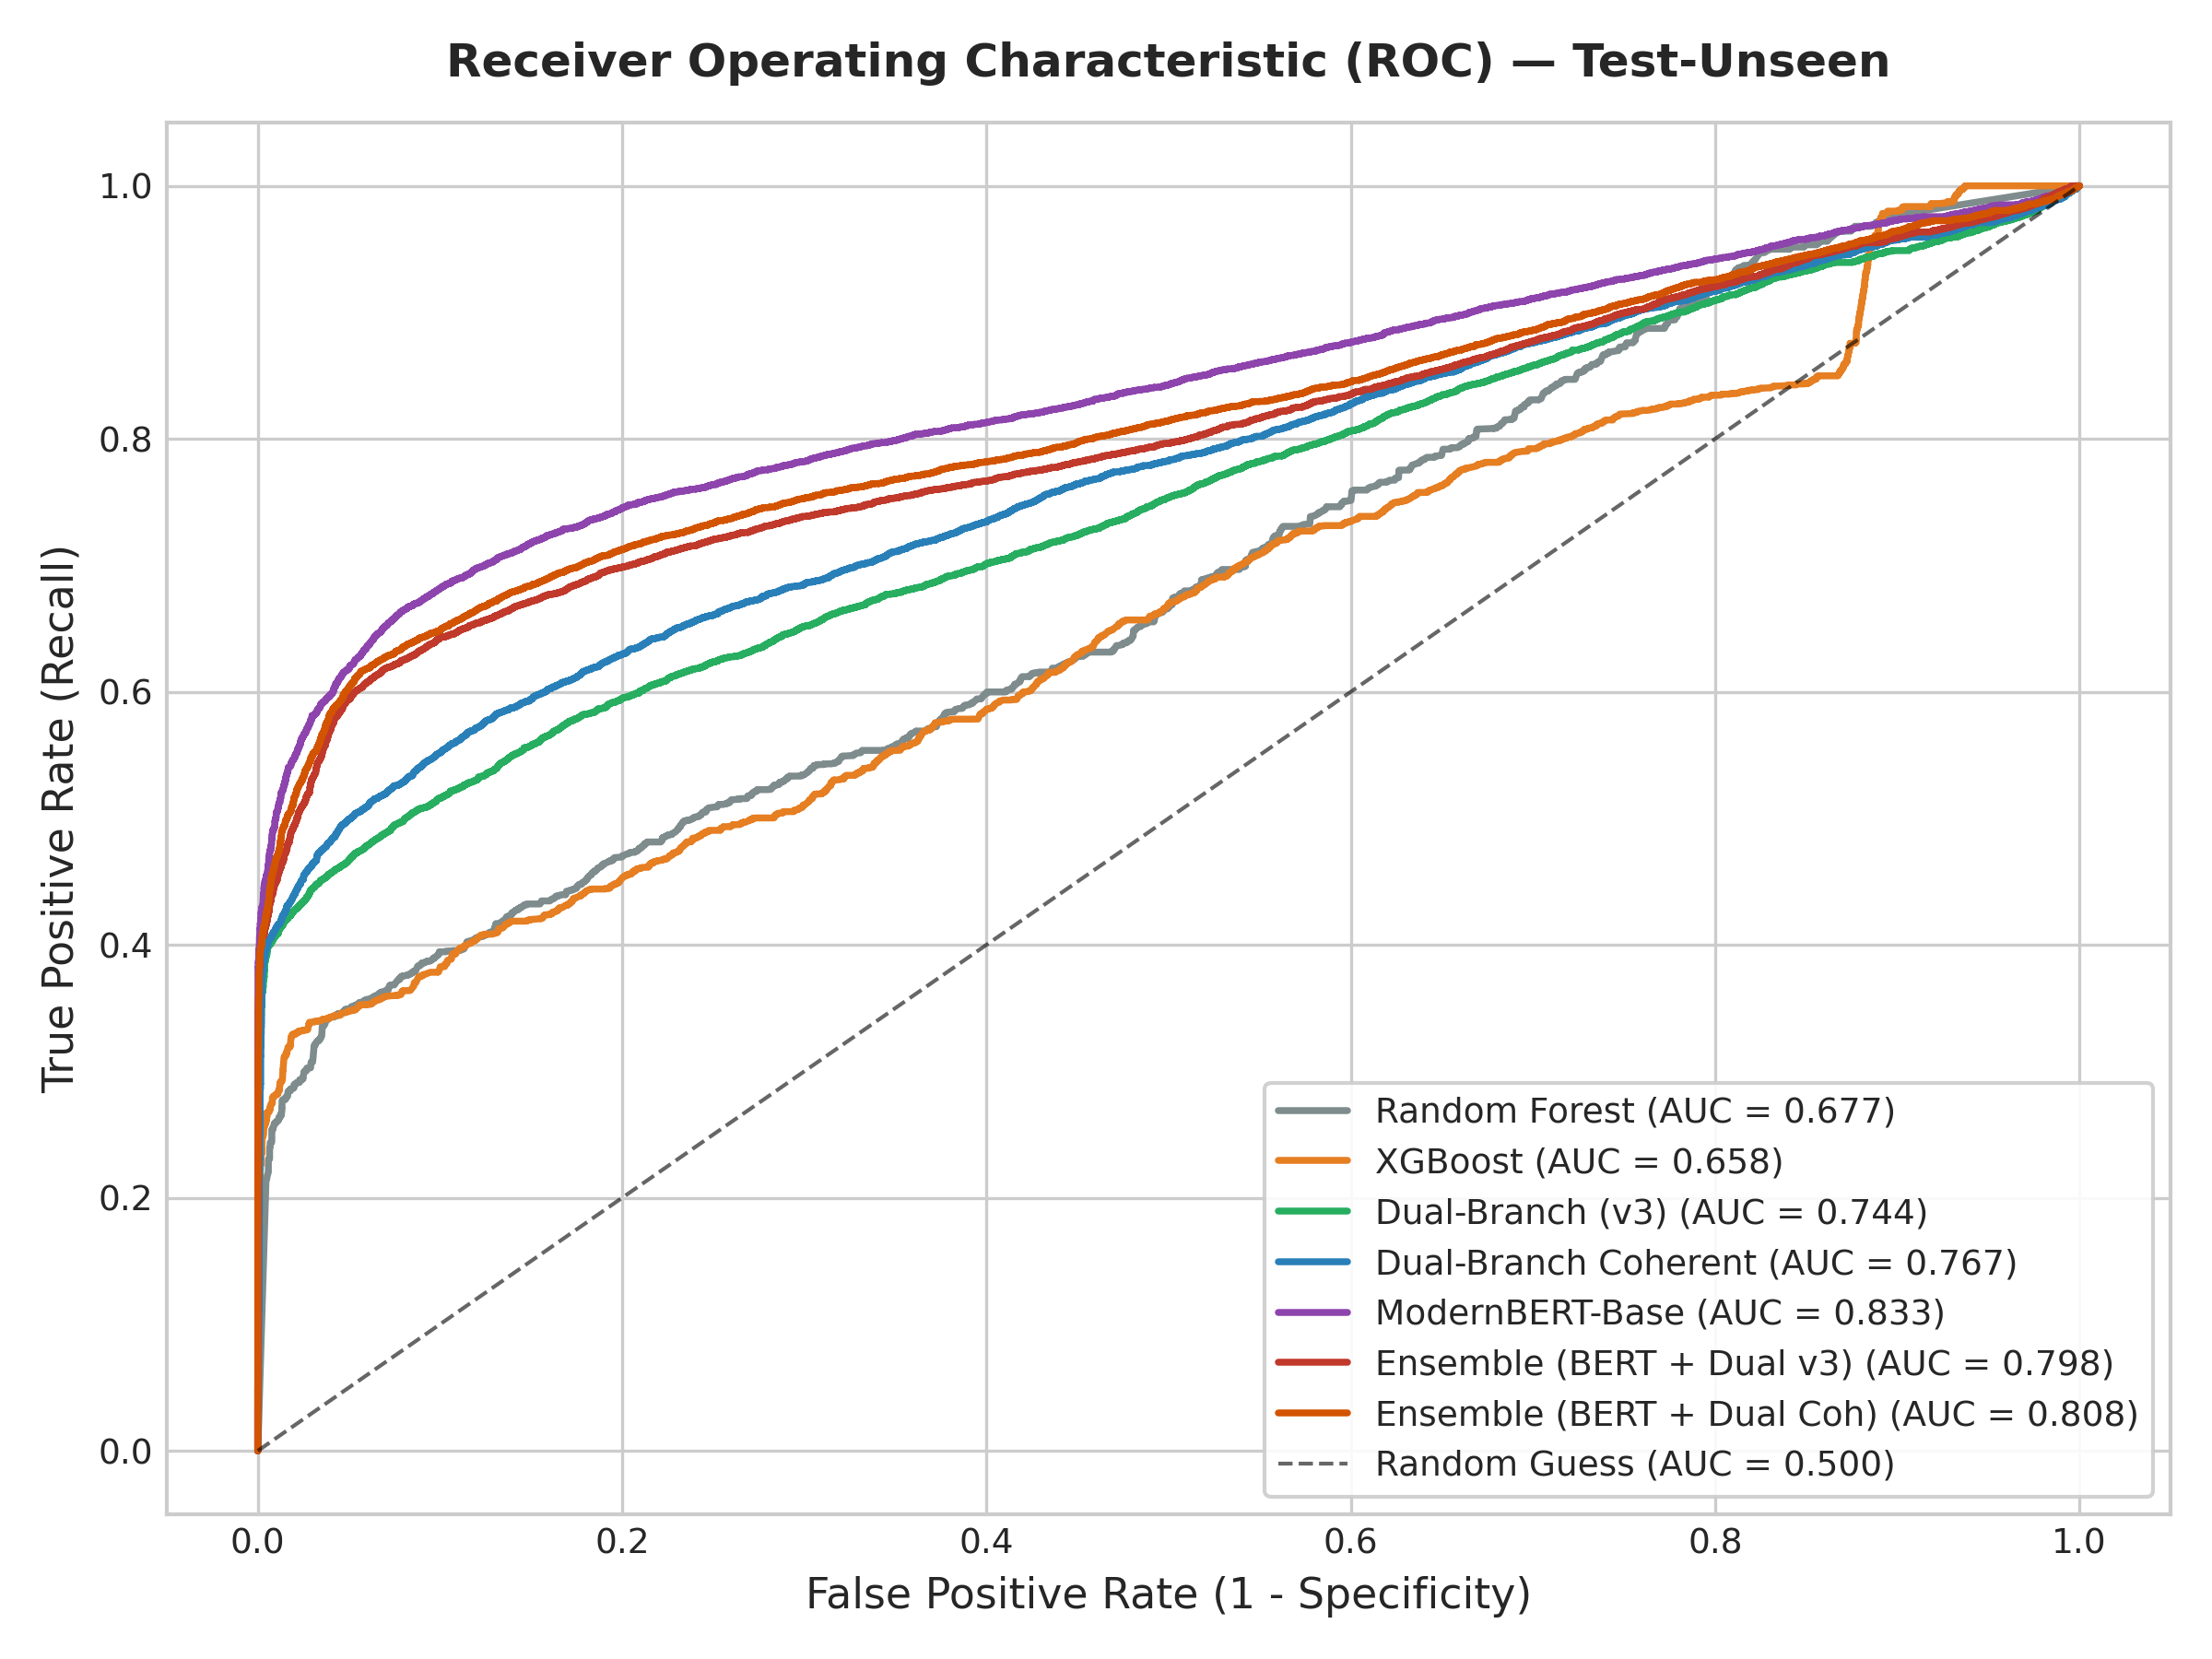

In [5]:
display(Image(filename=str(FIG_DIR / "fig1_roc_curves.png")))

### Figure 2: Precision-Recall (PR) Curves
Precision-Recall trade-off and Average Precision (PR-AUC). High PR-AUC reflects the ability to detect malicious domains while minimizing false alarms in operational networks.

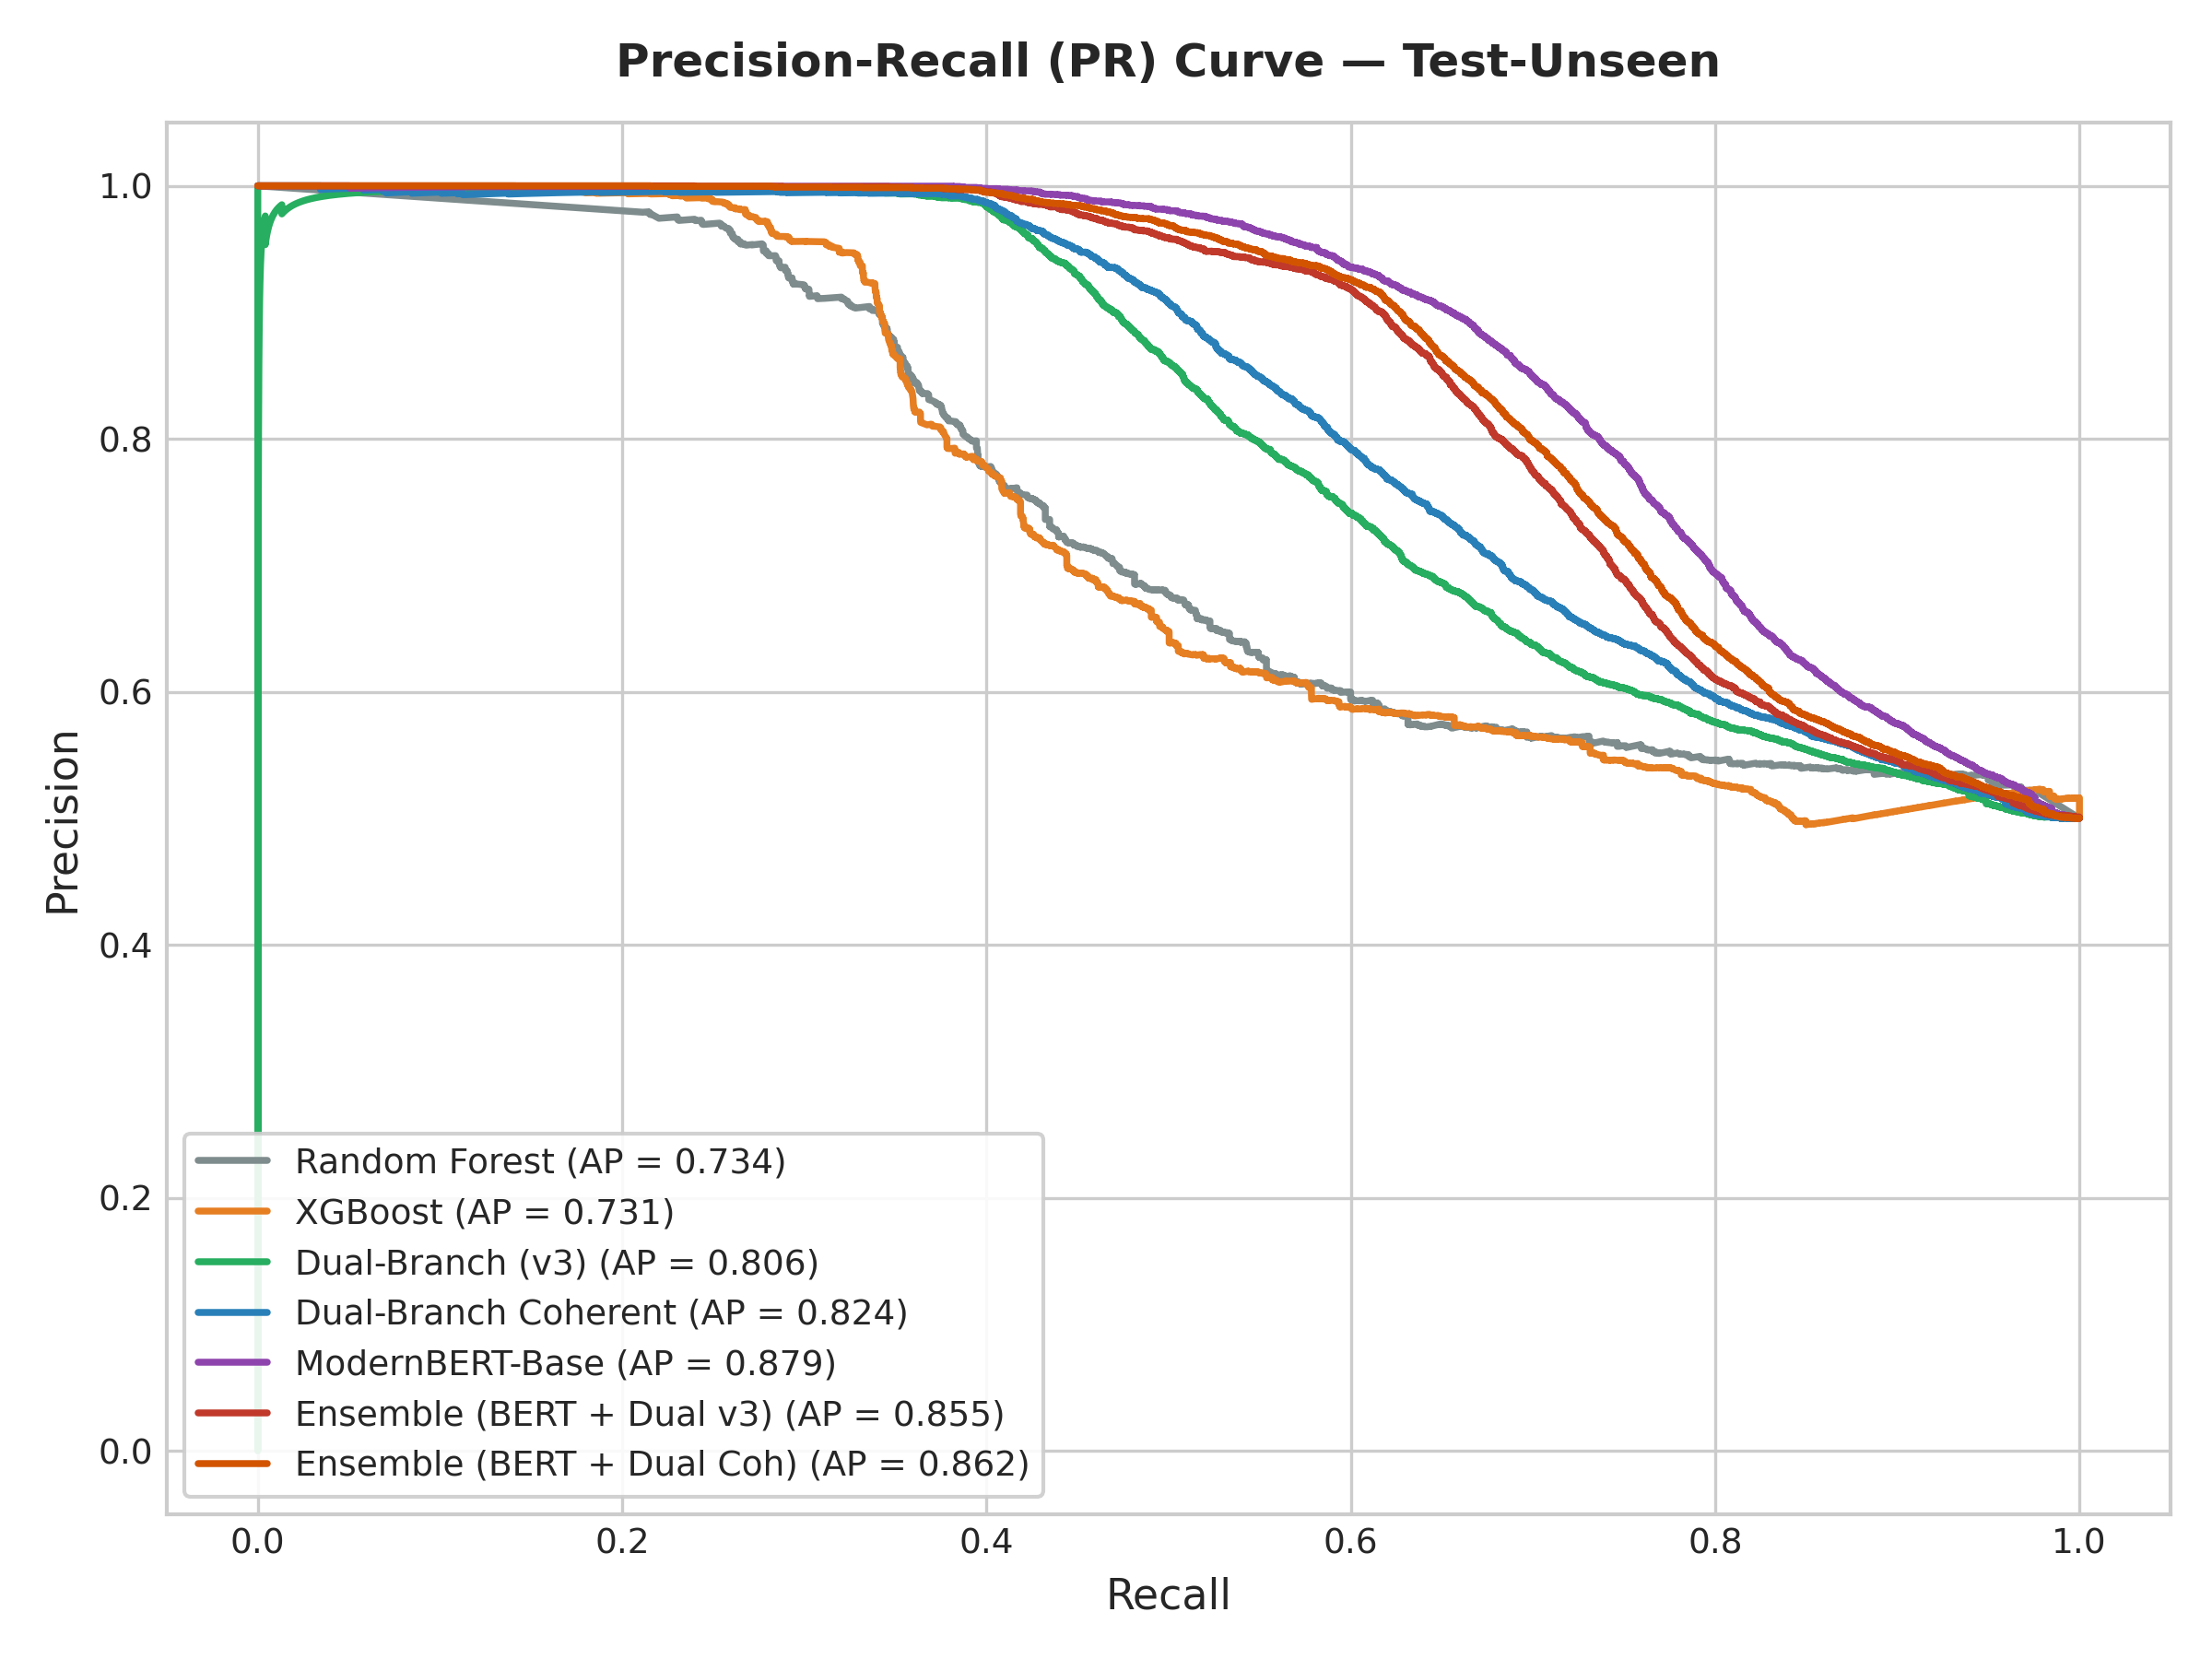

In [6]:
display(Image(filename=str(FIG_DIR / "fig2_pr_curves.png")))

### Figure 3: 7-Panel Confusion Matrix Grid
Complete breakdown of True Positives, False Positives, True Negatives, and False Negatives for all 7 architectures at standard threshold $\tau=0.50$.

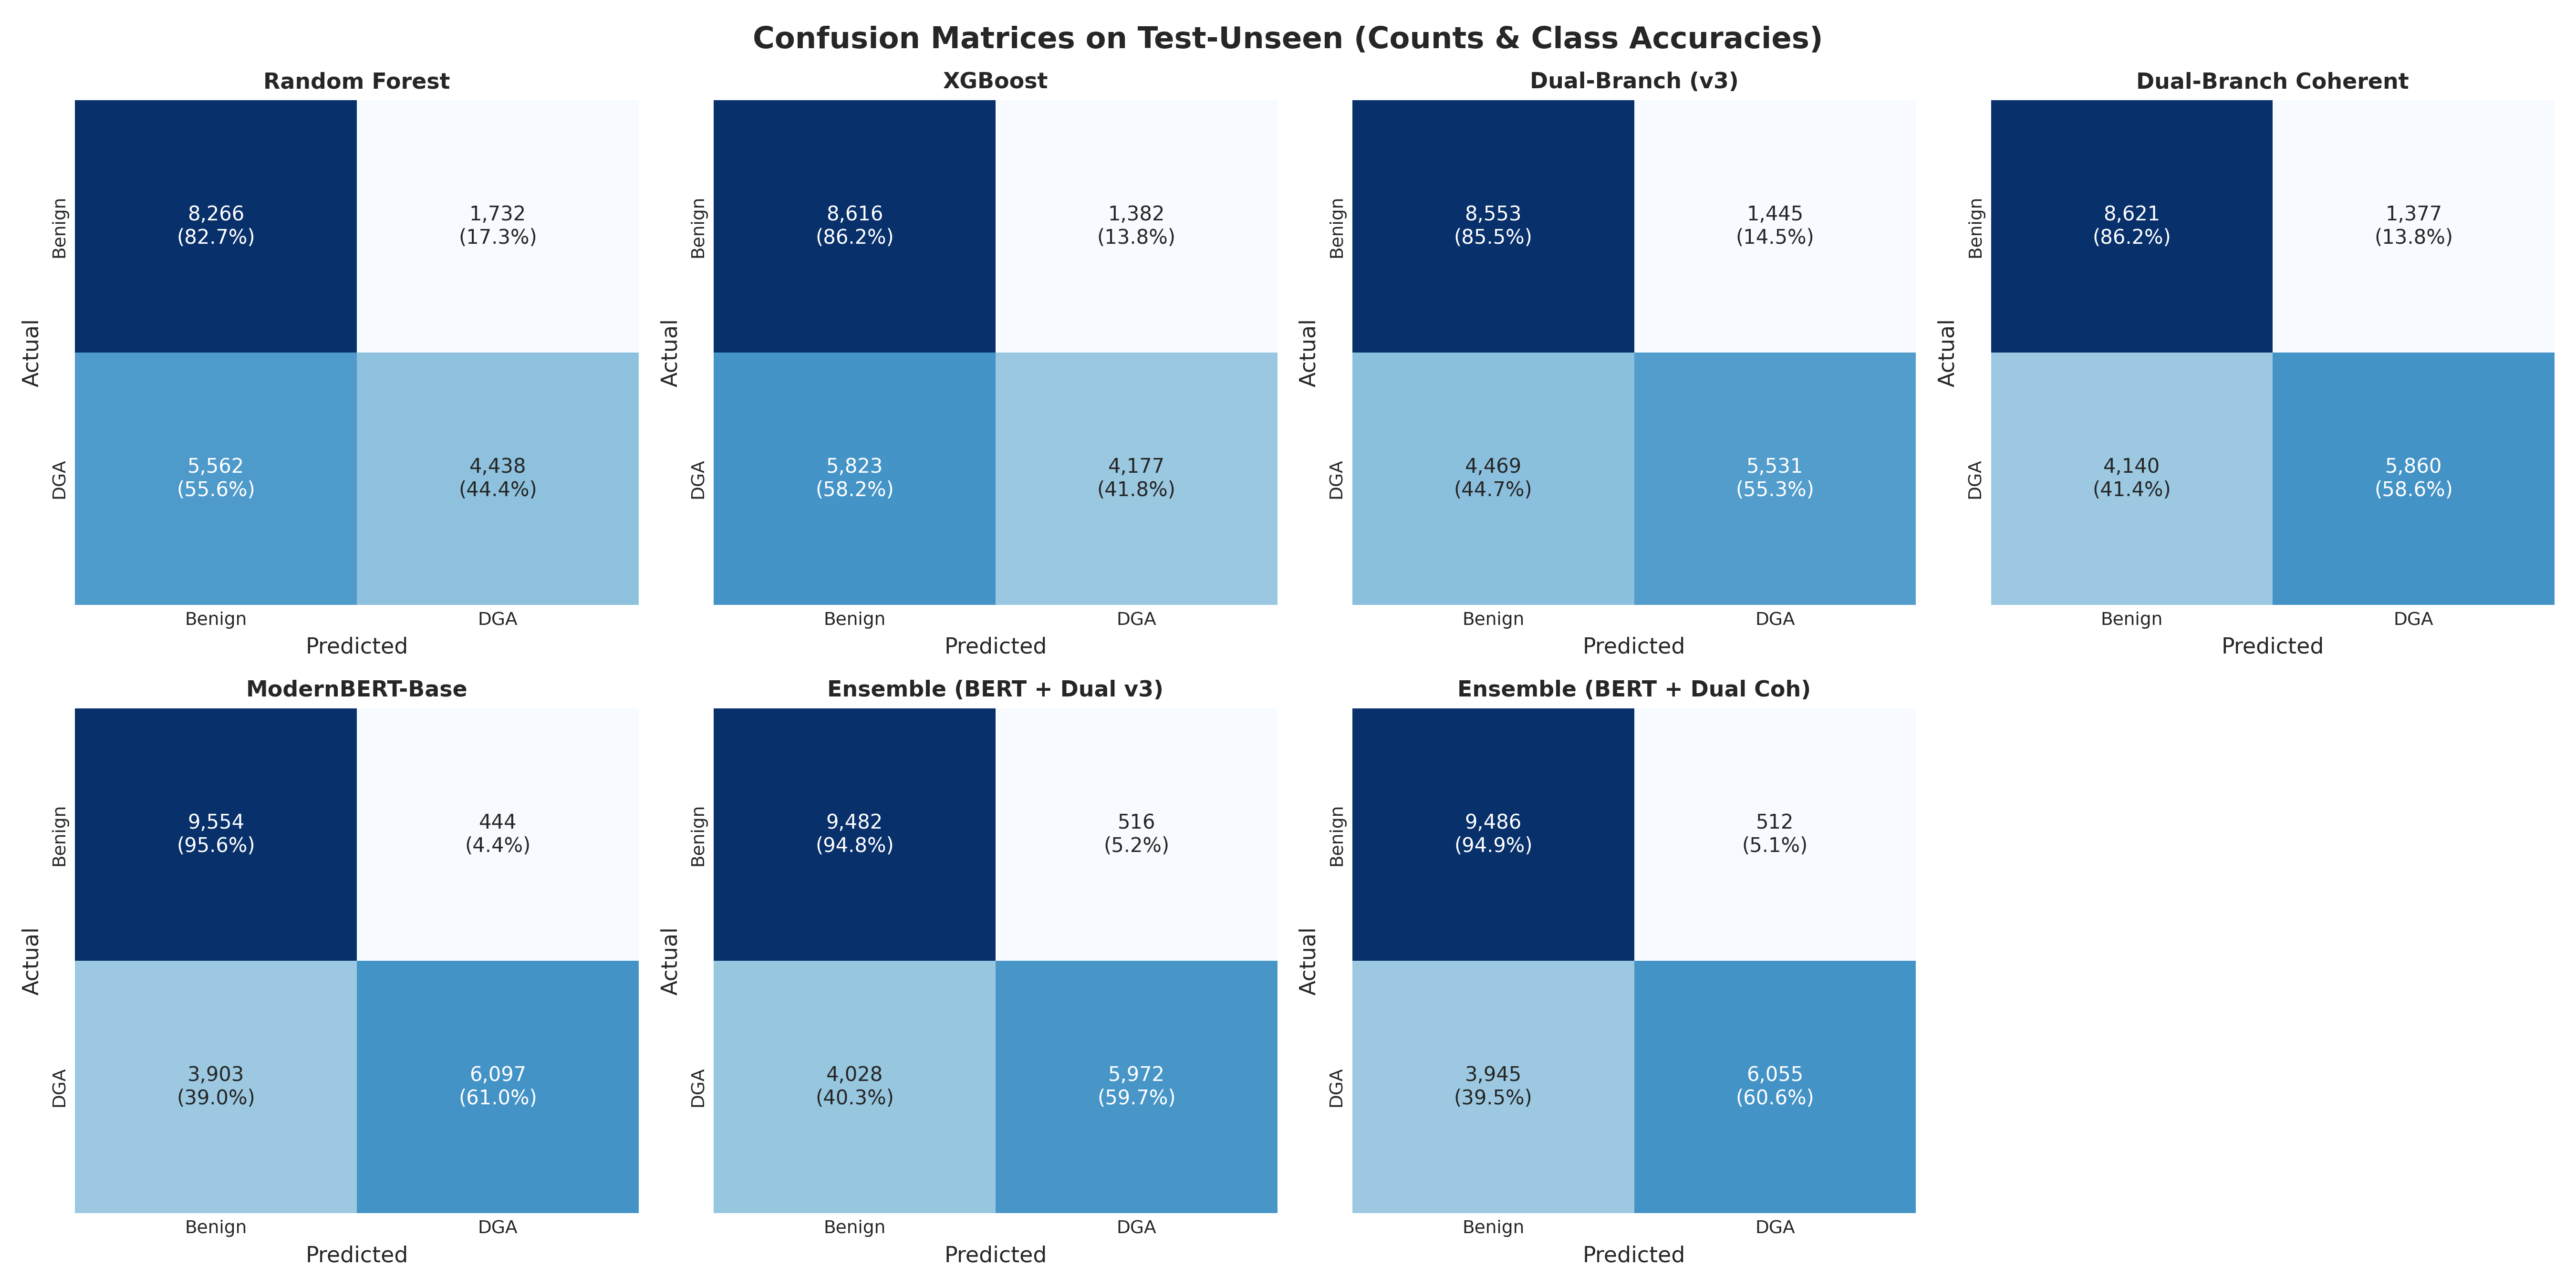

In [7]:
display(Image(filename=str(FIG_DIR / "fig3_confusion_matrices_grid.png")))

### Figure 4: Per-Family Recall & Specificity Bar Chart
Head-to-head grouped bar chart across all 6 classes. Note the decisive dominance of all deep models on non-wordlist families (`tinba`, `murofet` at ~100%), the significant uplift of Dual-Branch Coherent on `matsnu` (**17.60%** vs ModernBERT's **14.15%**), and ModernBERT's superior benign specificity (**95.56%**).

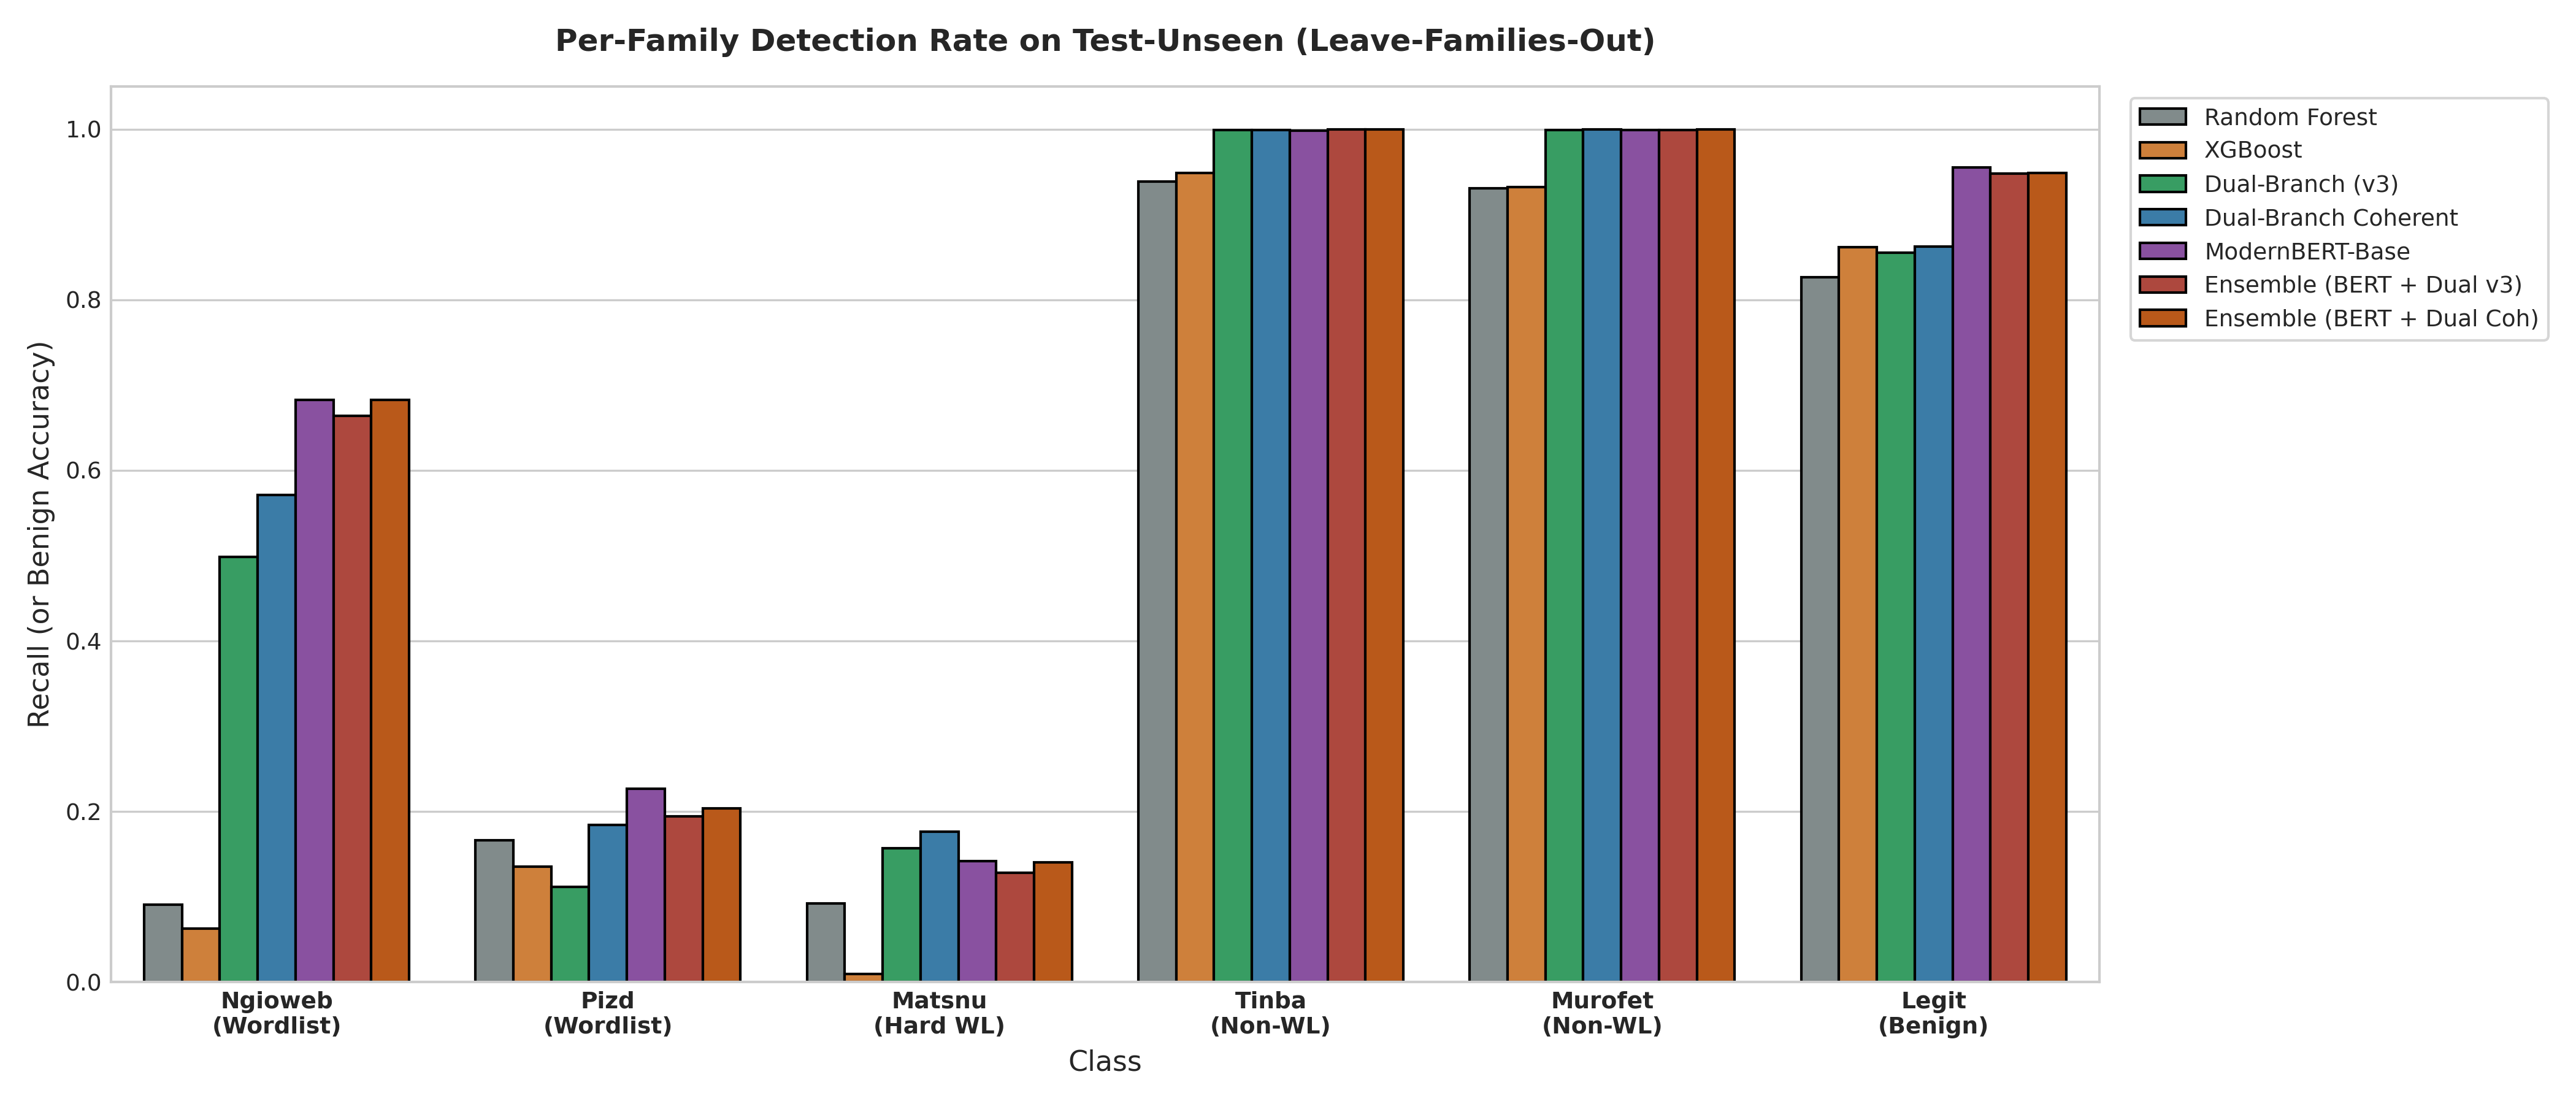

In [8]:
display(Image(filename=str(FIG_DIR / "fig4_per_family_recall_barchart.png")))

### Figure 5: Benchmark Anchor Comparison
Direct comparison against the published literature benchmarks:
- **Floor:** Drichel et al. (RAID 2022) baseline (19.4% F1)
- **Ceiling:** Leyva La O et al. (IEEE 2026) zero-shot wordlist ceiling (80.9% F1)
- All deep learning models clear the Drichel floor by up to 2.3×.

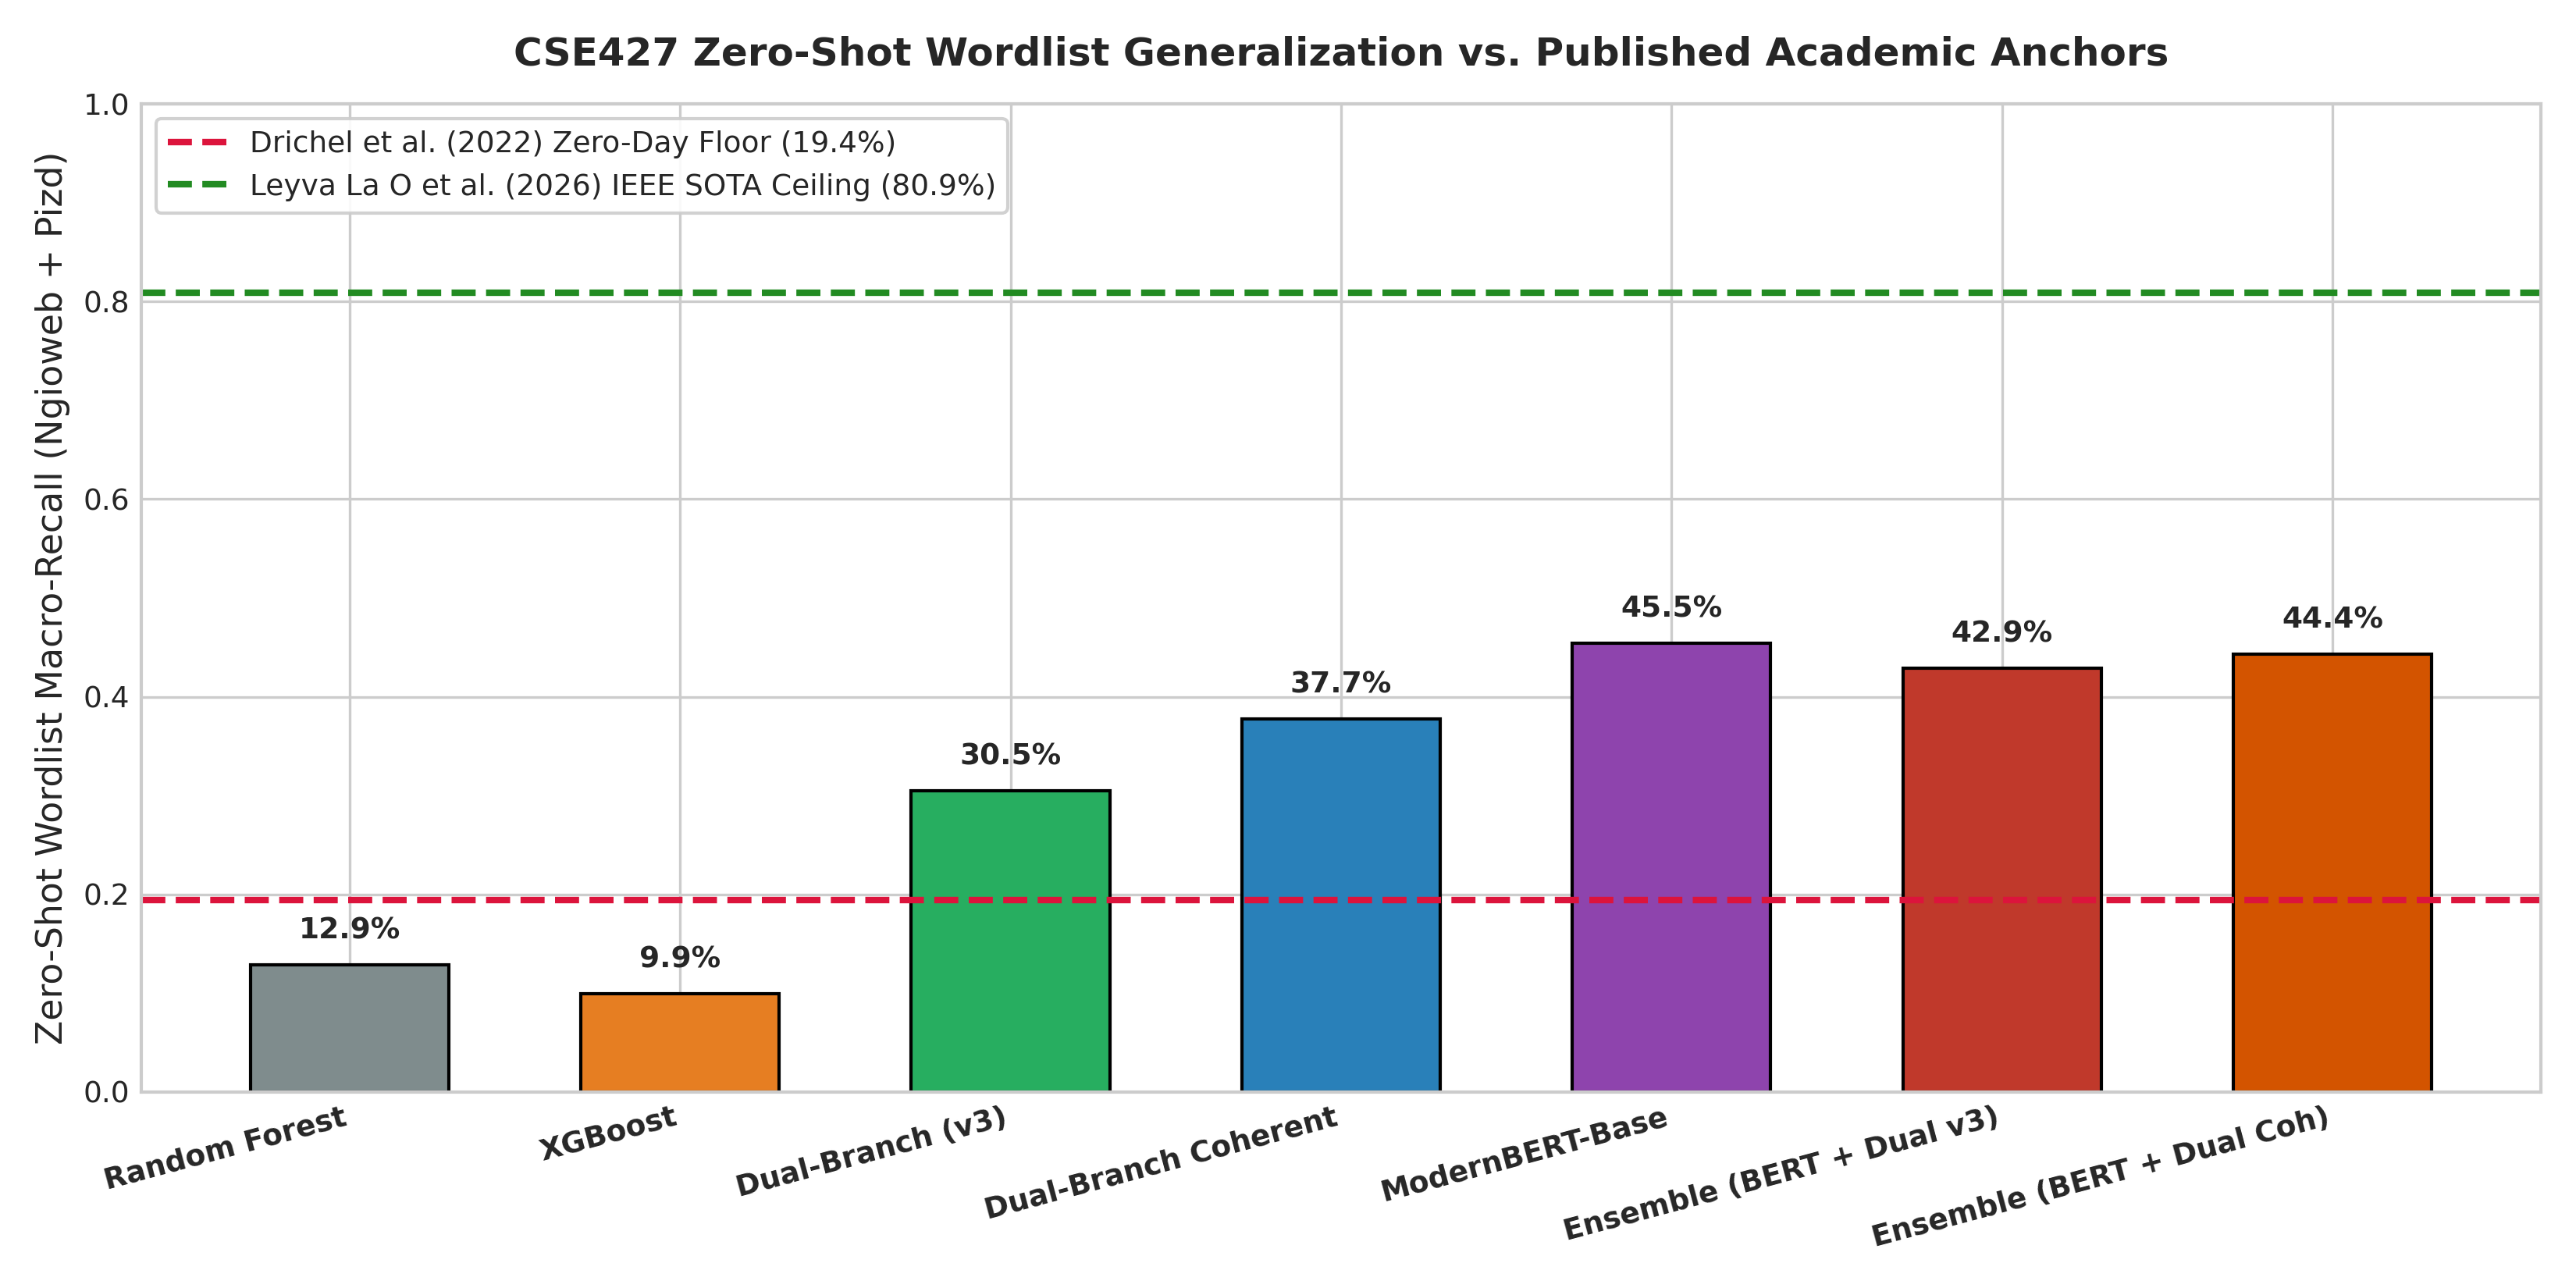

In [9]:
display(Image(filename=str(FIG_DIR / "fig5_benchmark_anchors_comparison.png")))

### Figure 6: Threshold Decision Boundary Trade-Off Curves
Plots Wordlist Detection Recall vs Benign Specificity as a function of decision threshold $\tau \in [0.01, 0.99]$. Demonstrates how security operators can calibrate the threshold according to deployment cost functions.

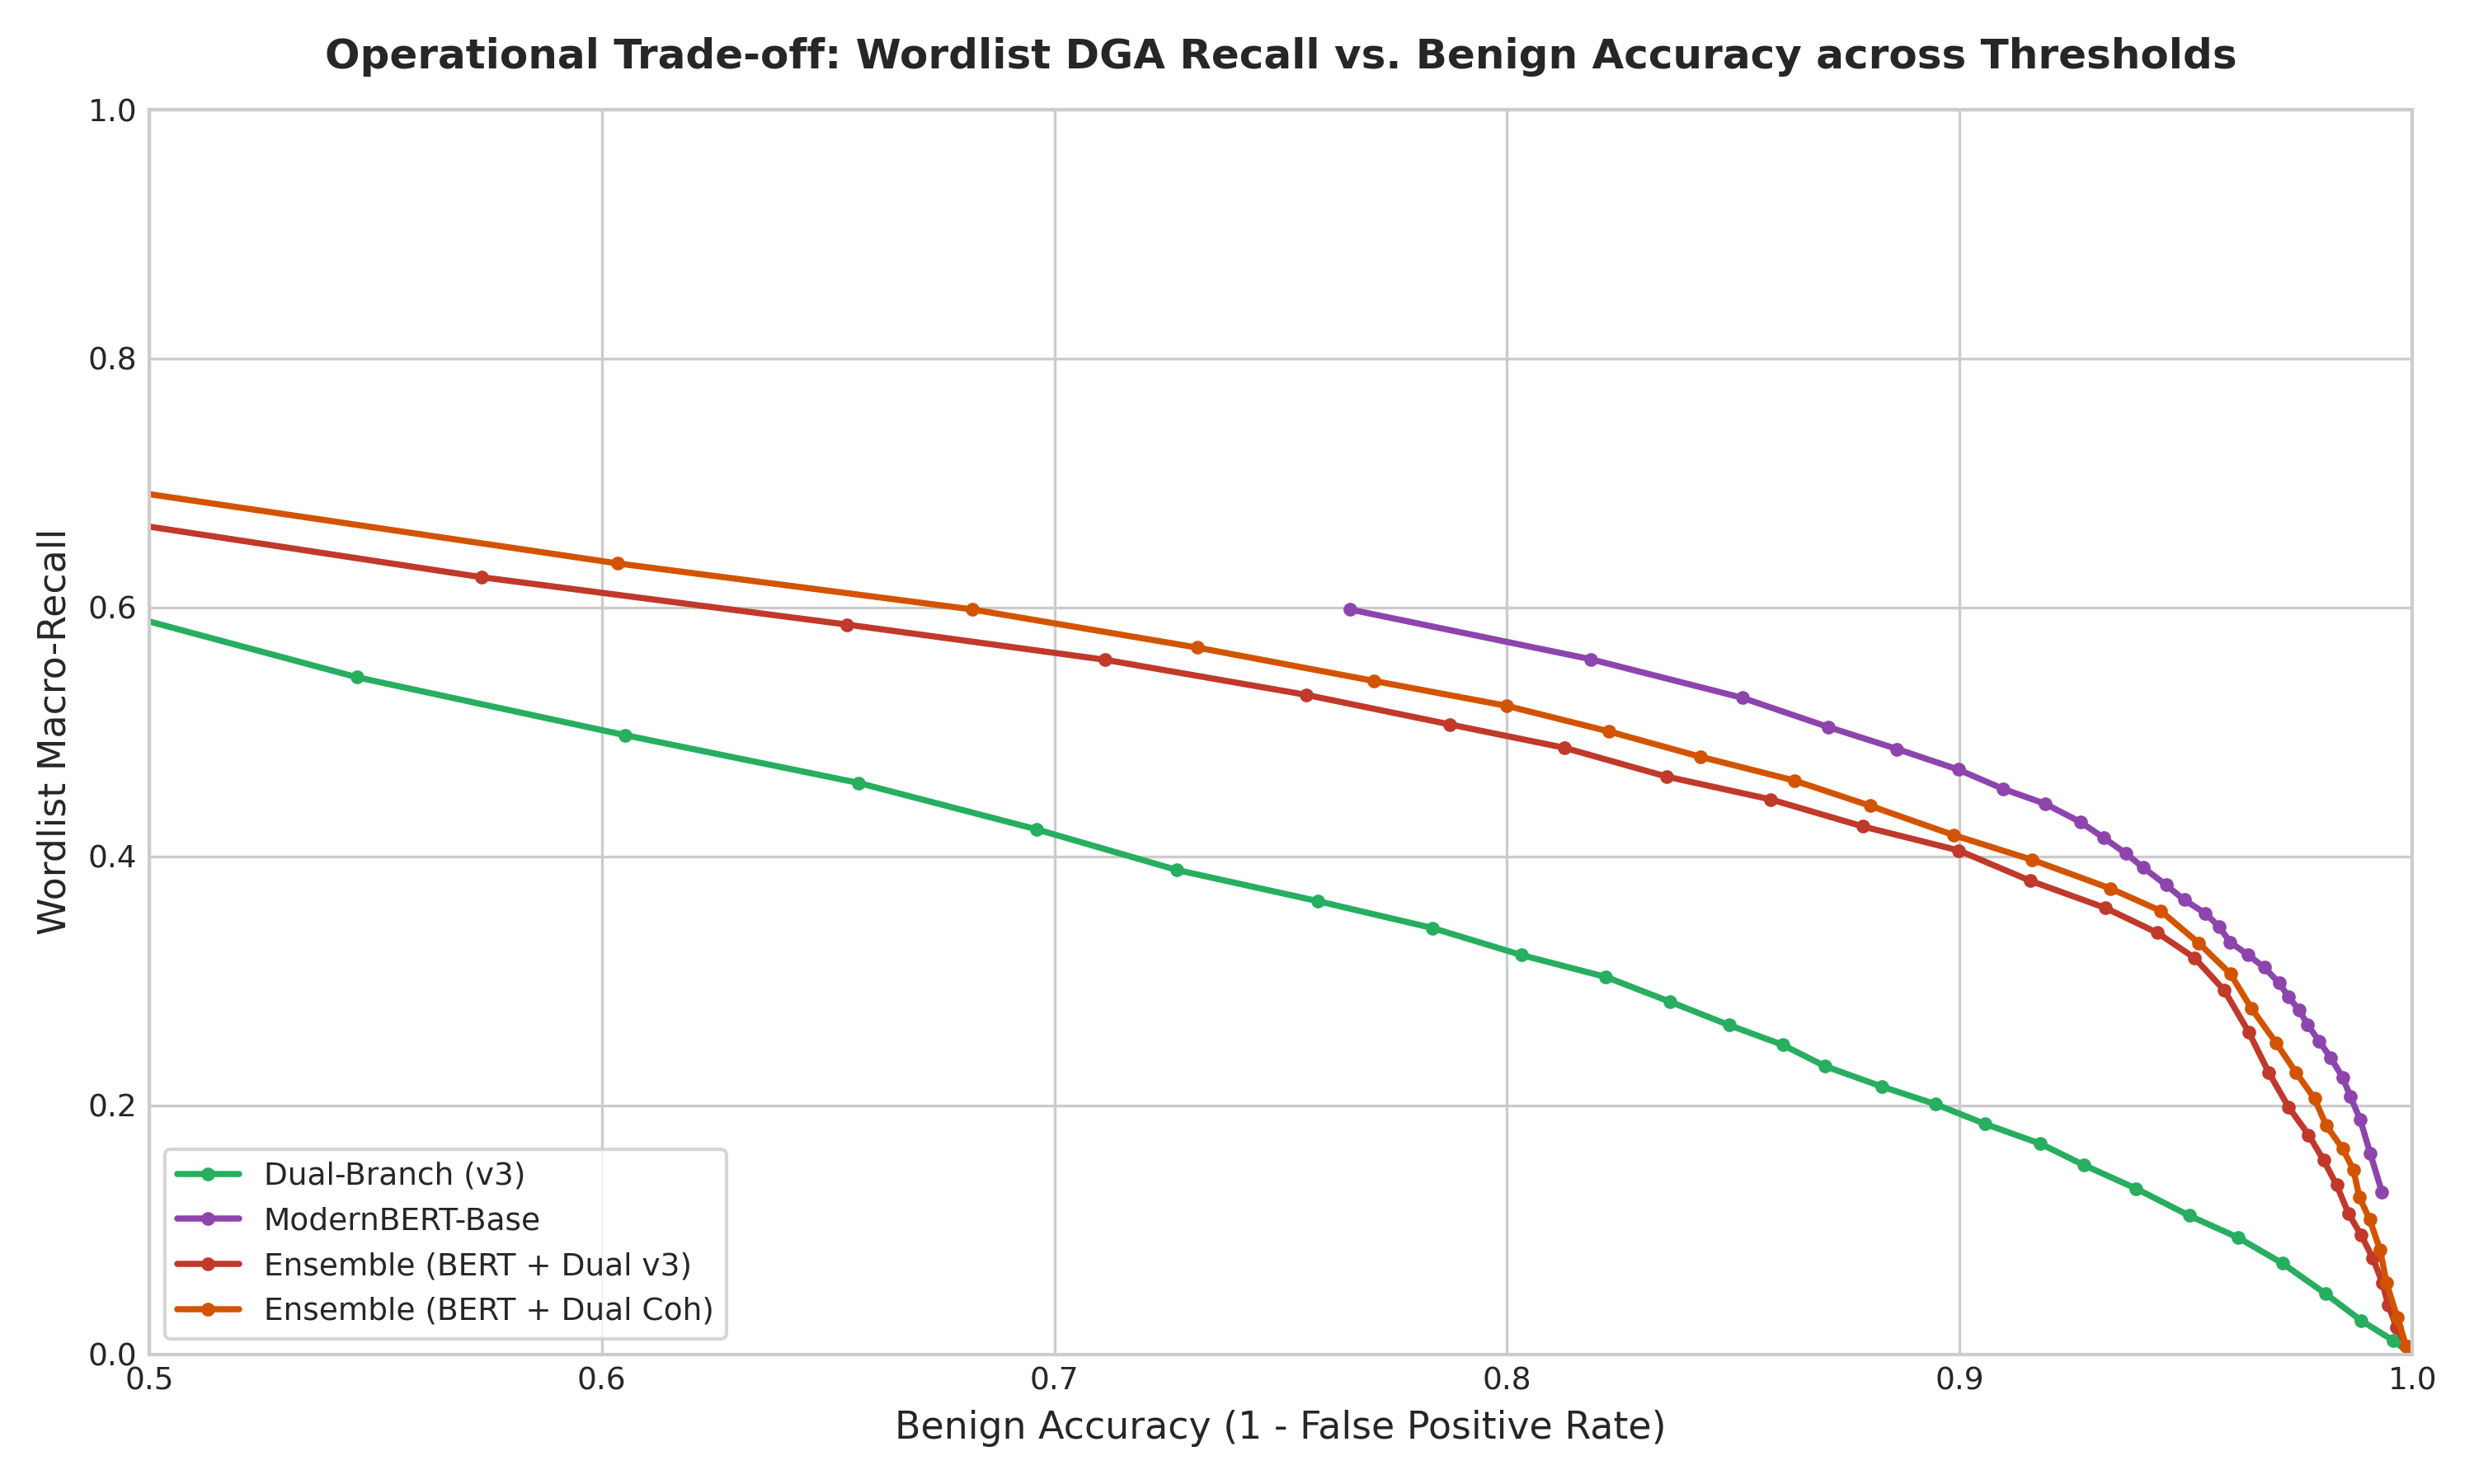

In [10]:
display(Image(filename=str(FIG_DIR / "fig6_threshold_tradeoff_curves.png")))

### Figure 7: Error Composition Donut Charts
Visual breakdown of total test errors into False Positives (benign flagged as DGA) vs False Negatives (DGA missed). ModernBERT has only 444 False Positives (10.2% of errors), whereas Dual-Branch models have ~1,377 False Positives (25.0% of errors).

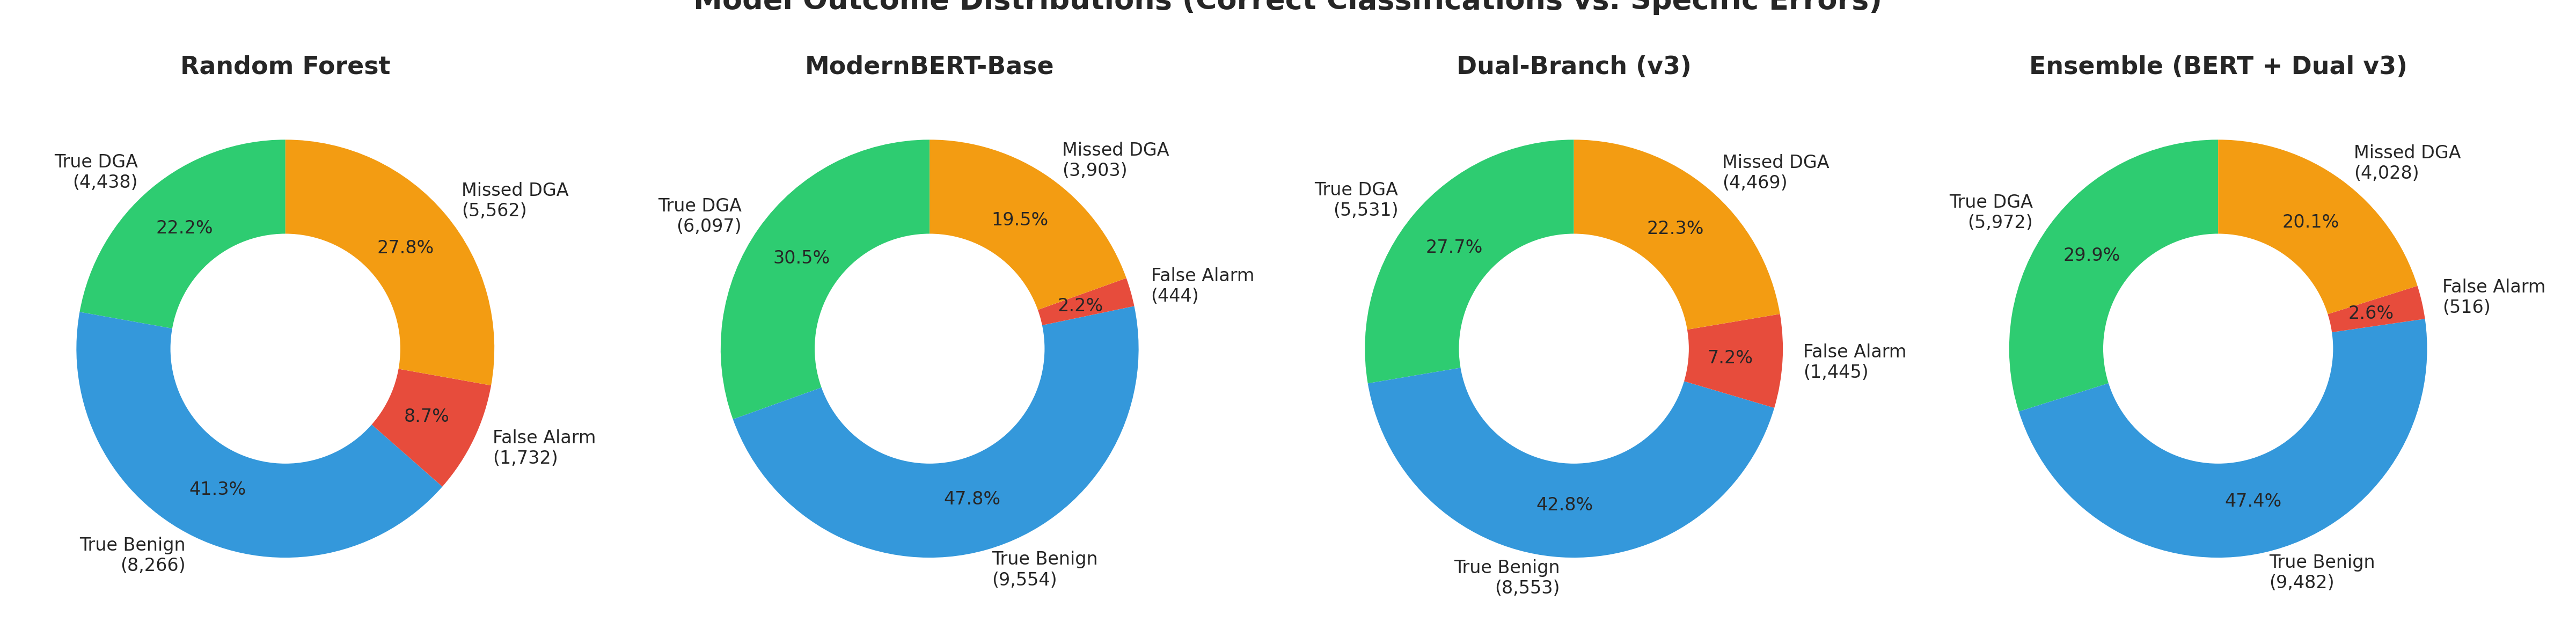

In [11]:
display(Image(filename=str(FIG_DIR / "fig7_error_breakdown_donuts.png")))

### Figure 8: 6-Axis Model Profiling Radar Chart
Multi-criteria comparison covering F1-Score, ROC-AUC, PR-AUC, Wordlist Macro Recall, Non-Wordlist Macro Recall, and Benign Specificity.

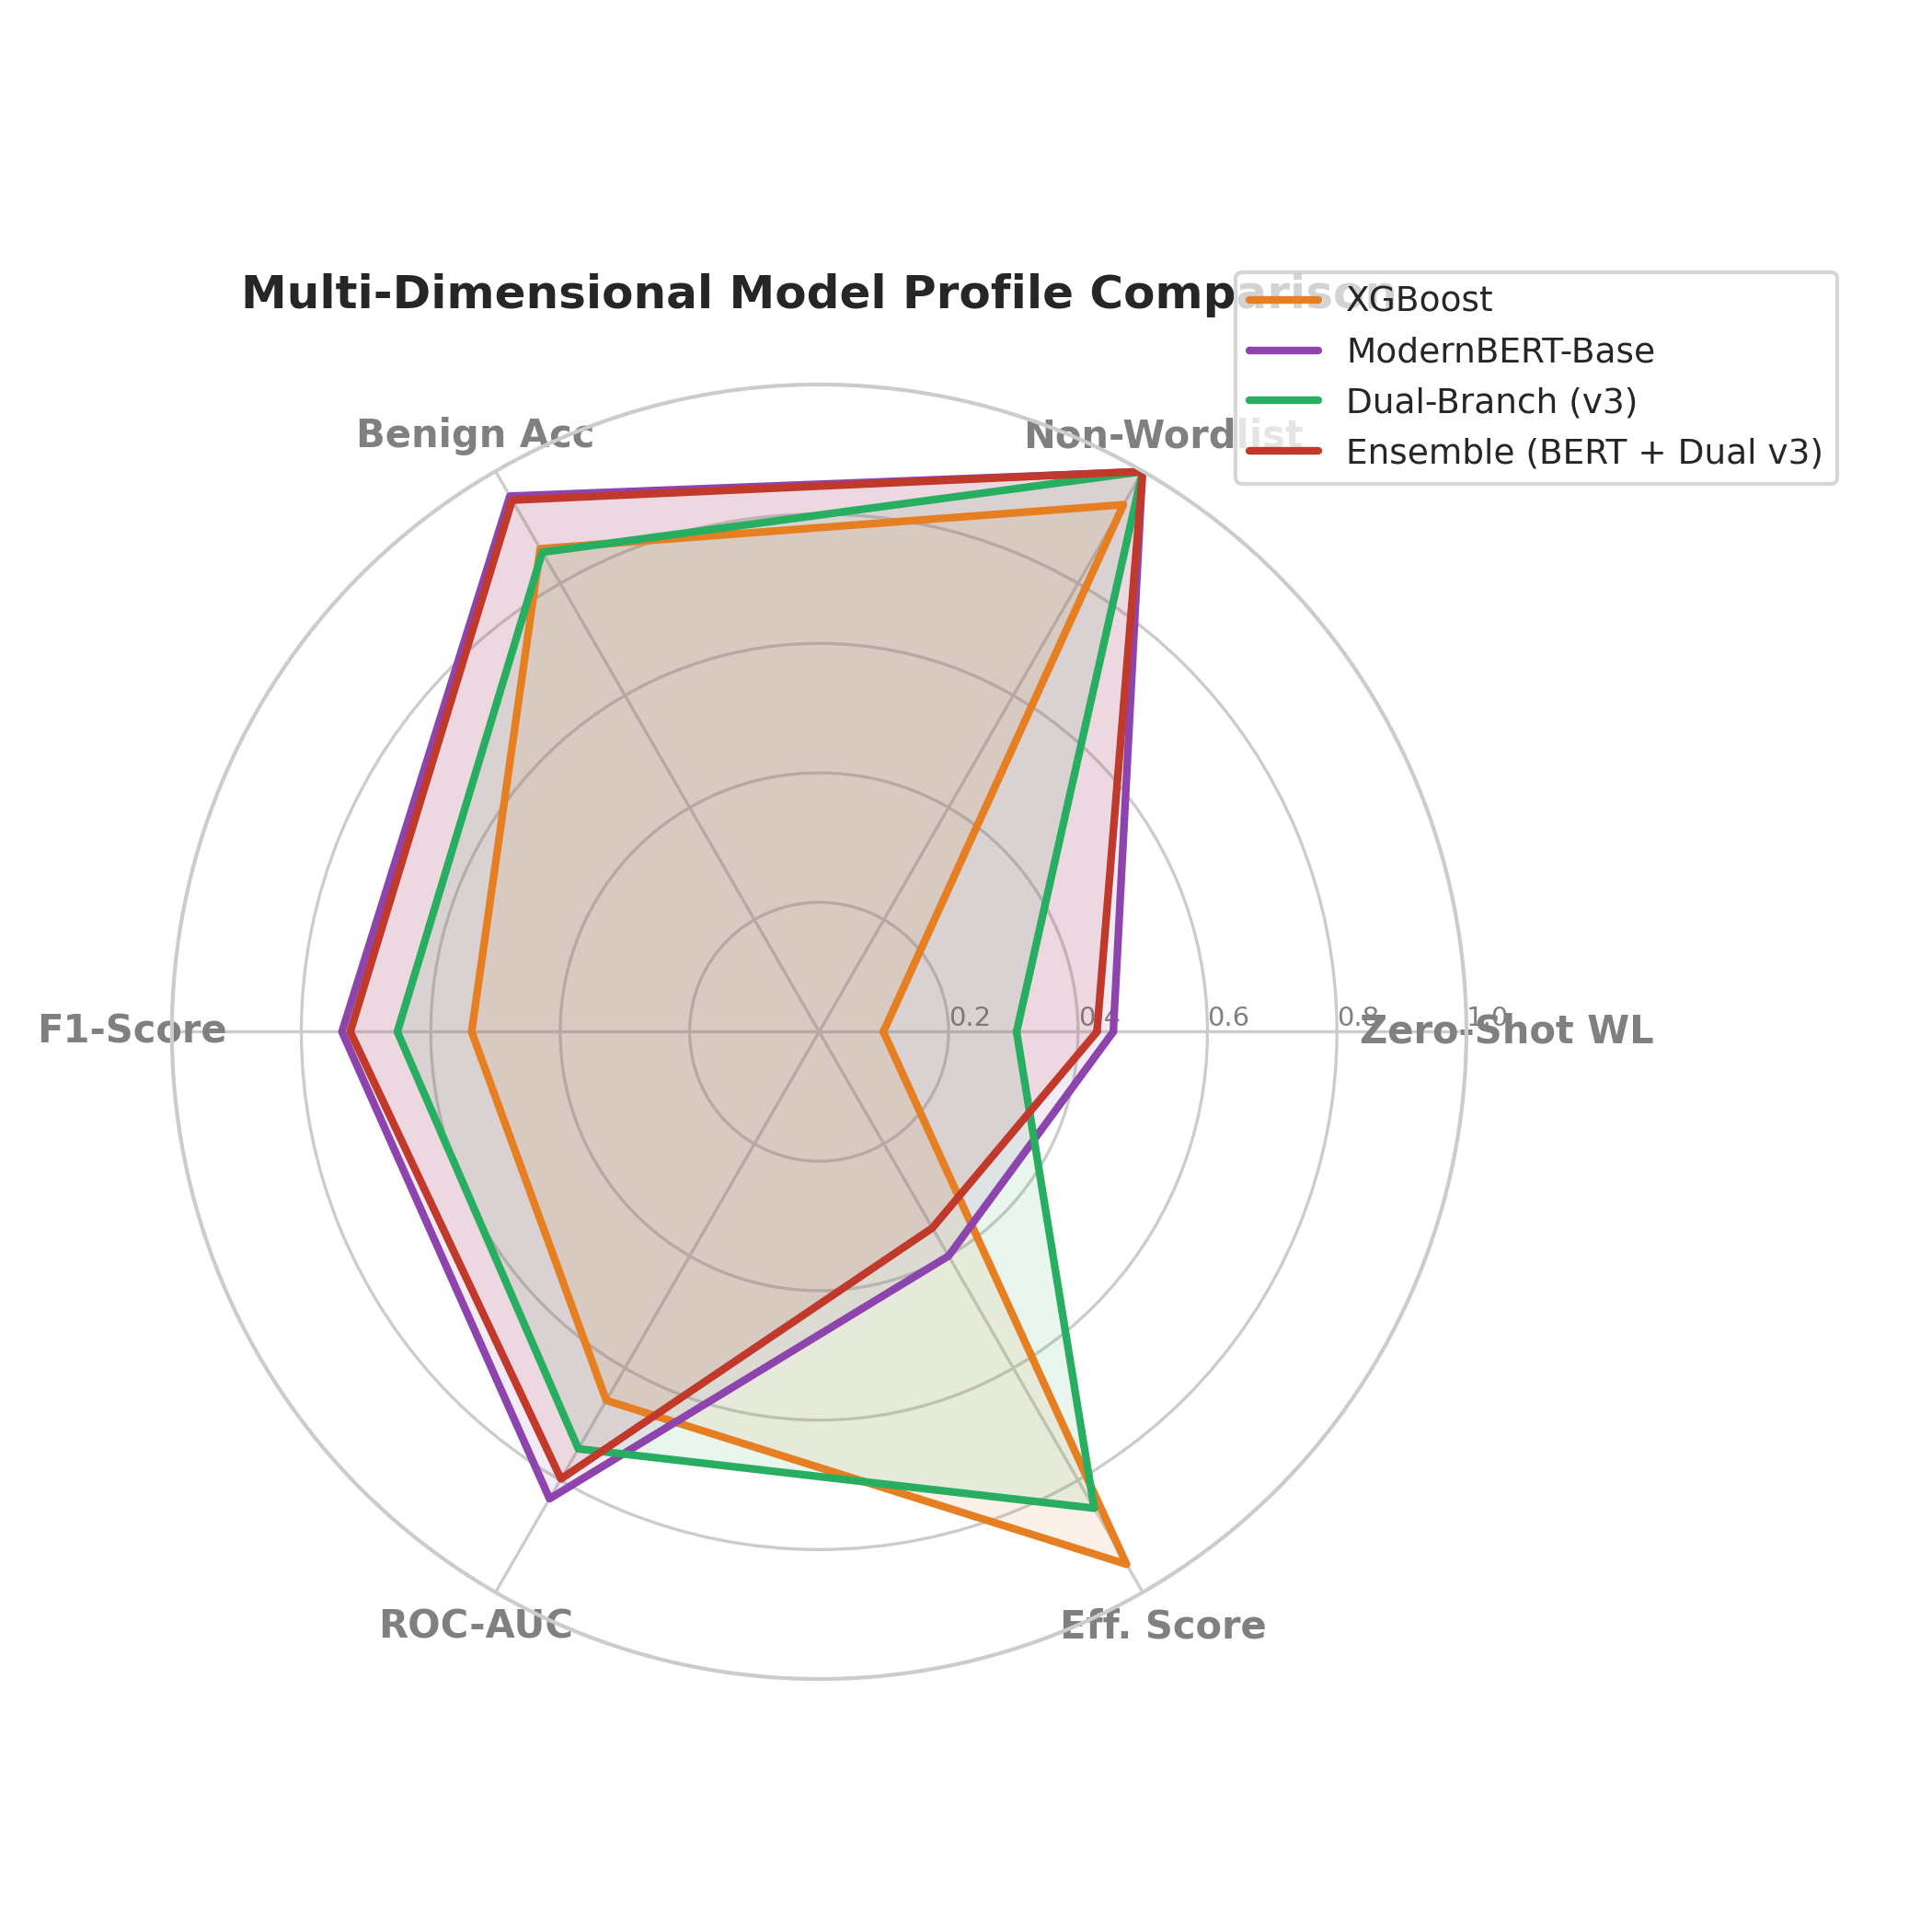

In [12]:
display(Image(filename=str(FIG_DIR / "fig8_radar_model_profile.png")))

## 5. LaTeX Code for Academic Paper / Project Report

The code below prints the ready-to-paste LaTeX tables for your IEEE/ACM paper submission.

In [13]:
print("% ==========================================================================")
print("% TABLE I: CSE427 FINAL TEST-UNSEEN BENCHMARK COMPARISON")
print("% ==========================================================================")
with open(TABLE_DIR / "final_test_benchmark_table.tex", "r") as f:
    print(f.read())

print("\n% ==========================================================================")
print("% TABLE II: DETAILED CLASSIFICATION METRICS")
print("% ==========================================================================")
with open(TABLE_DIR / "final_test_detailed_metrics.tex", "r") as f:
    print(f.read())

% ==========================================================================
% TABLE I: CSE427 FINAL TEST-UNSEEN BENCHMARK COMPARISON
% ==========================================================================
\begin{tabular}{lrrrrrrrr}
\toprule
Model & Zero-Shot WL (Ngioweb+Pizd) & Matsnu (Hard Case) & Overall Wordlist Macro & Non-Wordlist Macro & Benign Accuracy & F1-Score & ROC-AUC & PR-AUC \\
\midrule
Random Forest & 0.129 & 0.092 & 0.117 & 0.934 & 0.827 & 0.549 & 0.677 & 0.734 \\
XGBoost & 0.099 & 0.009 & 0.069 & 0.940 & 0.862 & 0.537 & 0.658 & 0.731 \\
Dual-Branch (v3) & 0.305 & 0.157 & 0.256 & 0.999 & 0.855 & 0.652 & 0.744 & 0.806 \\
Dual-Branch Coherent & 0.377 & 0.176 & 0.310 & 1.000 & 0.862 & 0.680 & 0.767 & 0.824 \\
ModernBERT-Base & 0.455 & 0.141 & 0.350 & 0.999 & 0.956 & 0.737 & 0.833 & 0.879 \\
Ensemble (BERT + Dual v3) & 0.429 & 0.128 & 0.329 & 1.000 & 0.948 & 0.724 & 0.798 & 0.855 \\
Ensemble (BERT + Dual Coh) & 0.444 & 0.141 & 0.343 & 1.000 & 0.949 & 0.731 & 0.808 & 0